<a href="https://colab.research.google.com/github/Nourin-Nusrat/CSE4261_DNN/blob/main/Assignment10/DNN_Assignment_10_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# DenoisingAutoencoder

In [2]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder: compress image to latent vector
        self.encoder = nn.Sequential(
            nn.Flatten(),                     # (1, 28, 28) → (784)
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 16)                 # Latent vector size = 16
        )

        # Decoder: reconstruct image from latent vector
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),                     # Output pixel values between 0 and 1
            nn.Unflatten(1, (1, 28, 28))      # (784) → (1, 28, 28)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Load MNIST Dataset

In [3]:
transform = transforms.ToTensor()
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(mnist, batch_size=128, shuffle=True)

# Initialize Model, Loss, Optimizer

In [4]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = DenoisingAutoencoder().to(device)
# criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# epochs = 40
# for epoch in range(epochs):
#     for images, _ in loader:
#         images = images.to(device)
#         outputs = model(images)
#         loss = criterion(outputs, images)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#     print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")
# print("Training finished.\n")

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 40
for epoch in range(epochs):
    model.train()
    for images, _ in loader:
        images = images.to(device)

        # 1. Add Gaussian noise to the input images
        noisy_images = images + 0.3 * torch.randn_like(images)
        noisy_images = torch.clamp(noisy_images, 0., 1.)  # Keep within valid range

        # 2. Forward pass using noisy images
        outputs = model(noisy_images)

        # 3. Loss: comparing output to original (clean) images
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

print("Training finished.\n")

Epoch [1/40], Loss: 0.0385
Epoch [2/40], Loss: 0.0311
Epoch [3/40], Loss: 0.0265
Epoch [4/40], Loss: 0.0249
Epoch [5/40], Loss: 0.0212
Epoch [6/40], Loss: 0.0195
Epoch [7/40], Loss: 0.0183
Epoch [8/40], Loss: 0.0164
Epoch [9/40], Loss: 0.0175
Epoch [10/40], Loss: 0.0167
Epoch [11/40], Loss: 0.0172
Epoch [12/40], Loss: 0.0151
Epoch [13/40], Loss: 0.0156
Epoch [14/40], Loss: 0.0149
Epoch [15/40], Loss: 0.0149
Epoch [16/40], Loss: 0.0135
Epoch [17/40], Loss: 0.0150
Epoch [18/40], Loss: 0.0155
Epoch [19/40], Loss: 0.0147
Epoch [20/40], Loss: 0.0126
Epoch [21/40], Loss: 0.0141
Epoch [22/40], Loss: 0.0145
Epoch [23/40], Loss: 0.0135
Epoch [24/40], Loss: 0.0116
Epoch [25/40], Loss: 0.0130
Epoch [26/40], Loss: 0.0128
Epoch [27/40], Loss: 0.0136
Epoch [28/40], Loss: 0.0120
Epoch [29/40], Loss: 0.0133
Epoch [30/40], Loss: 0.0128
Epoch [31/40], Loss: 0.0124
Epoch [32/40], Loss: 0.0139
Epoch [33/40], Loss: 0.0128
Epoch [34/40], Loss: 0.0127
Epoch [35/40], Loss: 0.0131
Epoch [36/40], Loss: 0.0122
E

# Generate Noise Vectors (mean=5, variance=1)

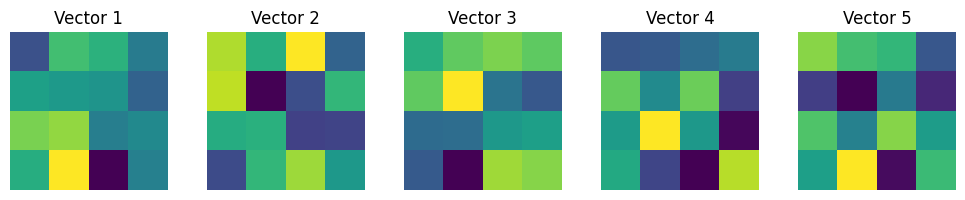

In [12]:
noise_vectors = torch.normal(mean=5.0, std=1.0, size=(5, 16))
plt.figure(figsize=(10, 2))
for i in range(5):
    vector_image = noise_vectors[i].reshape(4, 4).cpu().numpy()
    plt.subplot(1, 5, i + 1)
    plt.imshow(vector_image)
    plt.title(f"Vector {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Plot the Results

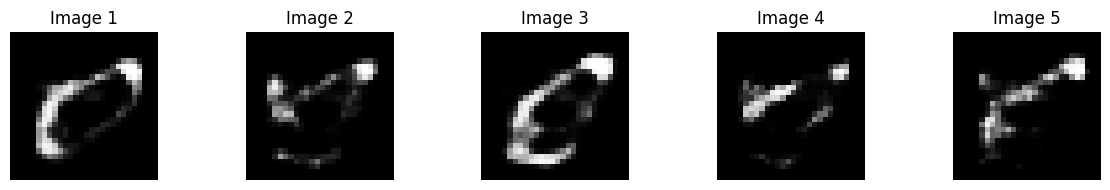

In [30]:
noise_vectors = torch.normal(mean=5.0, std=2.0, size=(5, 16)).to(device)
with torch.no_grad():
    generated_images = model.decoder(noise_vectors).cpu()
plt.figure(figsize=(12, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_images[i][0], cmap='gray')
    plt.title(f"Image {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()
